In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
import pandas as pd
df = pd.read_csv("High-resolution-Multimodal new.csv")
print("--- LAB1: Dataset Exploration ---")
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe(include="all"))
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Records: {df.duplicated().sum()}")
print("\nClass Distribution (benchmark_50_region_name):")
print(df["benchmark_50_region_name"].value_counts().head(10))

--- LAB1: Dataset Exploration ---
Dataset Shape: (115, 8)

Data Types:
original_class_id                          int64
original_voxel_value                     float64
original_region_name                         str
benchmark_50_label_id                      int64
benchmark_50_region_name                     str
mapping_status                               str
benchmark_label_composition                  str
n_original_labels_in_benchmark_region        str
dtype: object

Summary Statistics:
        original_class_id  original_voxel_value original_region_name  \
count          115.000000            114.000000                  115   
unique                NaN                   NaN                   63   
top                   NaN                   NaN    cerebral peduncle   
freq                  NaN                   NaN                    2   
mean            57.000000            120.236842                  NaN   
std             33.341666             73.516394                  NaN  

--- LAB2: Data Visualization ---


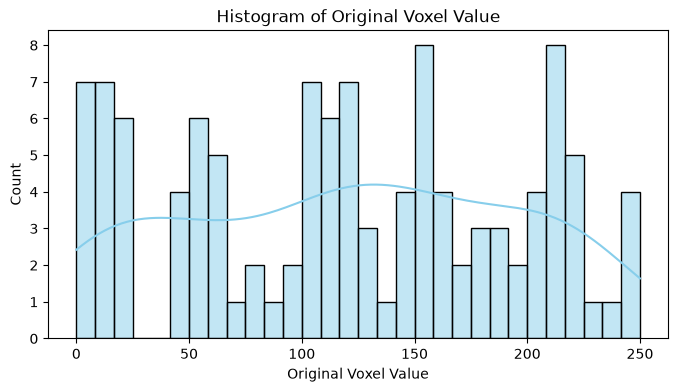

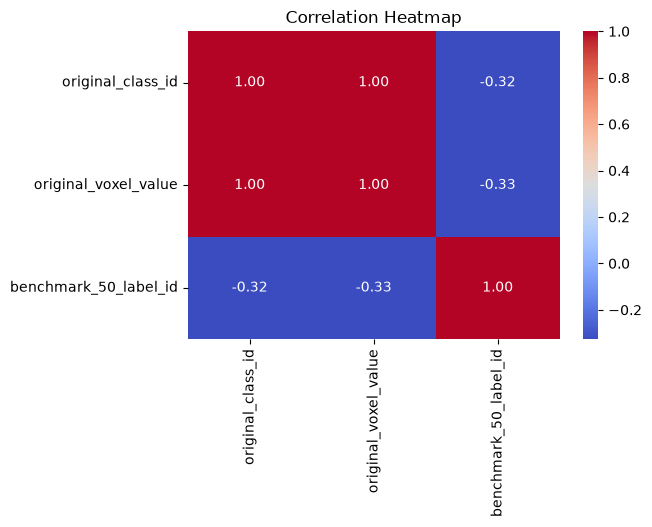

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
df = pd.read_csv("High-resolution-Multimodal new.csv")
print("--- LAB2: Data Visualization ---")
plt.figure(figsize=(8, 4))
sns.histplot(df["original_voxel_value"].dropna(), kde=True, bins=30, color="skyblue")
plt.title("Histogram of Original Voxel Value")
plt.xlabel("Original Voxel Value")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(6, 4))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("High-resolution-Multimodal new.csv")
print("--- Part 3: Data Cleaning ---")
df_before = df.copy()
voxel_median = df["original_voxel_value"].median()
df["original_voxel_value"] = df["original_voxel_value"].fillna(voxel_median)
print("-> Handled missing values (Filled with Median).")
df = df.drop_duplicates()
print("-> Performed duplicate removal.")
df["n_original_labels_in_benchmark_region"] = df[
    "n_original_labels_in_benchmark_region"
].replace("-", "0")
print("-> Corrected incorrect data ('-' replaced with '0').")
df["n_original_labels_in_benchmark_region"] = df[
    "n_original_labels_in_benchmark_region"
].astype(int)
print("-> Converted data type to integer.")
print("\n[Comparison for original_voxel_value]")
print(f"Before -> Mean: {df_before['original_voxel_value'].mean():.2f} | Median: {df_before['original_voxel_value'].median():.2f}")
print(f"After  -> Mean: {df['original_voxel_value'].mean():.2f} | Median: {df['original_voxel_value'].median():.2f}")
df.to_csv("cleaned_dataset.csv", index=False)

--- Part 3: Data Cleaning ---
-> Handled missing values (Filled with Median).
-> Performed duplicate removal.
-> Corrected incorrect data ('-' replaced with '0').
-> Converted data type to integer.

[Comparison for original_voxel_value]
Before -> Mean: 120.24 | Median: 121.00
After  -> Mean: 120.24 | Median: 121.00


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("cleaned_dataset.csv")
print("--- Part 4: Feature Engineering ---")

# 1. Label Encoding (เหมาะสำหรับข้อมูลที่มีการเรียงลำดับหรือจัดกลุ่มสั้นๆ)
le = LabelEncoder()
df["mapping_status_encoded"] = le.fit_transform(df["mapping_status"])
print("-> Label Encoding Completed for 'mapping_status'")
print(df[["mapping_status", "mapping_status_encoded"]].drop_duplicates().head())

# 2. One-Hot Encoding (ขยายข้อมูลเป็นคอลัมน์ 0 หรือ 1 แยกกัน)
df_encoded = pd.get_dummies(
    df, columns=["benchmark_label_composition"], prefix="comp", dtype=int
)
print("\n-> One-Hot Encoding Completed for 'benchmark_label_composition'")
print(df_encoded.filter(like="comp_").head())

--- Part 4: Feature Engineering ---
-> Label Encoding Completed for 'mapping_status'
            mapping_status  mapping_status_encoded
0               background                       0
1   excluded_to_background                       1
24     mapped_to_50_region                       2

-> One-Hot Encoding Completed for 'benchmark_label_composition'
   comp_-  comp_merged_multiple_original_labels  comp_single_original_label
0       1                                     0                           0
1       1                                     0                           0
2       1                                     0                           0
3       1                                     0                           0
4       1                                     0                           0
